In [18]:
import pandas as pd
df = pd.read_csv("report_synthetic.csv")

In [17]:
df.columns

Index(['trace_name', 'uuid', 'memory_requirement', 'cpu_requirement',
       'download_path', 'trace_file', 'slab_size', 'purpose', 'wsr',
       'slab_cnt', 'file_name', 'wss', 'num_slab_classes',
       'number_of_requests', 'allocSizes', 'duration_ns', 'ops', 'throughput',
       'moveOnSlabRelease', 'lruRefreshSec', 'poolResizeIntervalSec',
       'poolRebalanceIntervalSec', 'rebalanceStrategy', 'cacheSizeMB',
       'rebalanceDiffRatio', 'wakeUpRebalancerEveryXReqs', 'lru2qHotPct',
       'lru2qColdPct', 'allocator', 'rebalanceOnRecordAccess', 'generator',
       'replayGeneratorConfig', 'useTraceTimer', 'repeatTraceReplay',
       'repeatOpCount', 'onlySetIfMiss', 'enableLookaside', 'timestampFactor',
       'numThreads', 'prepopulateCache', 'zstdTrace', 'compressed',
       'traceFileName', 'numOps', '_rebalancerNumRuns', '_ramEvictions',
       '_getMissRatio', '_deltaStats', '_mhCVs', '_poolUsageFraction',
       '_rebalancerAvgRebalanceTimeMs', '_evicAttempts', '_allocFailure

In [19]:
def remap_df(df):
    df = df.copy()

    # 1. Rebalance strategy mapping
    def map_rebalance_strategy(x):
        if x == "marginal-hits-new":
            return "marginal-hits-tuned"
        elif x == "marginal-hits-old":
            return "marginal-hits"
        else:
            return x

    df["rebalance_strategy"] = df["rebalanceStrategy"].apply(map_rebalance_strategy)
    df = df[(df['maxDecayInterval'].isna()) | (df['maxDecayInterval'] == 50_000)]
    df = df[(df['countColdTailHitsOnly'].isna()) | (df['countColdTailHitsOnly'] == True)]

    #Append maxDecayInterval if not null
    def append_max_decay(row):
        val = row.get("maxDecayInterval", None)
        base = row["rebalance_strategy"]
        if pd.notnull(val):
            try:
                val = int(val)
                suffix = f"-{val//1000}k"
            except Exception:
                suffix = f"-{val}"
            return f"{base}{suffix}"
        return base

    #df["rebalance_strategy"] = df.apply(append_max_decay, axis=1)

    # 2. Allocator mapping
    def map_allocator(x):
        if x == "TINYLFUTail":
            return "TINYLFU"
        elif x == "SIMPLE2Q":
            return "LRU"
        else:
            return x

    df["allocator"] = df["allocator"].apply(map_allocator)

    # 3. Tag mapping
    def map_tag(row):
        if row["rebalanceStrategy"] in ["marginal-hits-new", "marginal-hits-old"] and row["allocator"] == "LRU2Q":
            val = row.get("countColdTailHitsOnly", False)
            if pd.notnull(val) and bool(val):
                return "cold"
            else:
                return "warm-cold"
        else:
            return None

    df["tag"] = df.apply(map_tag, axis=1)

    # 4. Add suffix to rebalance_strategy based on threshold fields
    def add_threshold_suffix(row):
        suffix = ""
        ai = row.get("thresholdAI", False)
        ad = row.get("thresholdAD", False)
        mi = row.get("thresholdMI", False)
        md = row.get("thresholdMD", False)
        if pd.notnull(ai) and pd.notnull(ad) and pd.notnull(mi) and pd.notnull(md):
            if bool(ai) and bool(ad):
                suffix = "-aiad"
            elif bool(mi) and bool(md):
                suffix = "-mimd"
            elif bool(ai) and bool(md):
                suffix = "-aimd"
        return str(row["rebalance_strategy"]) + suffix if suffix else row["rebalance_strategy"]
    #df["rebalance_strategy"] = df.apply(add_threshold_suffix, axis=1)

    # 5. Rename columns
    rename_dict = {
        "_missRatio": "miss_ratio",
        "_rebalancerNumRebalancedSlabs": "n_rebalanced_slabs",
        "wakeUpRebalancerEveryXReqs": "monitor_interval",
        "_allocFailures": "n_alloc_failures"
    }
    df = df.rename(columns=rename_dict)

    # 6. Select columns to keep
    keep_cols = [
        "trace_name", "number_of_requests", "wsr", "slab_size", "slab_cnt",
        "rebalance_strategy", "allocator", "tag", "throughput", "rebalanced_slabs",
        "miss_ratio", "n_rebalanced_slabs", "monitor_interval", "n_alloc_failures", "uuid", 
        "rebalanceDiffRatio", "slab_cnt"
    ]
    keep_cols = [col for col in keep_cols if col in df.columns]
    return df[keep_cols]

In [20]:
import numpy as np

def add_miss_ratio_reduction_from_disabled(df):
    df = df.copy()
    df = df.sort_values(["trace_name", "wsr", "allocator"])
    reduction_series = pd.Series(np.nan, index=df.index)

    group_cols = ["trace_name", "wsr", "allocator"]
    for _, group in df.groupby(group_cols):
        baseline = group[group["rebalance_strategy"] == "disabled"]
        if baseline.empty:
            baseline_miss = np.nan
        else:
            baseline_miss = baseline.iloc[0]["miss_ratio"]
        for idx, row in group.iterrows():
            reduction = baseline_miss - row["miss_ratio"] if pd.notnull(baseline_miss) and pd.notnull(row["miss_ratio"]) else np.nan
            reduction_series.at[idx] = reduction

    df["miss_ratio_reduction_from_disabled"] = reduction_series
    return df

In [57]:
df['throughput']

0       268568.165579
1       278757.178821
2       668447.008285
3       301616.974133
4        97160.618413
            ...      
2060    551847.132909
2061     78379.654813
2062    270476.274568
2063    486997.518445
2064    301257.483418
Name: throughput, Length: 2065, dtype: float64

In [21]:
def add_miss_ratio_reduction_from_lru_disabled(df):
    """
    For each group of (trace_name, wsr), use the row with allocator=='LRU' and rebalance_strategy=='disabled' as baseline.
    For each row in the group, compute miss_ratio_reduction_from_lru_disabled = baseline_miss_ratio - row['miss_ratio'].
    """
    df = df.copy()
    reduction_series = pd.Series(np.nan, index=df.index)
    group_cols = ["trace_name", "wsr"]

    # Build a lookup for baseline miss_ratio
    baseline_lookup = (
        df[(df["allocator"] == "LRU") & (df["rebalance_strategy"] == "disabled")]
        .set_index(group_cols)["miss_ratio"]
        .to_dict()
    )

    for idx, row in df.iterrows():
        key = (row["trace_name"], row["wsr"])
        baseline_miss = baseline_lookup.get(key, np.nan)
        if pd.notnull(baseline_miss) and pd.notnull(row["miss_ratio"]):
            reduction_series.at[idx] = baseline_miss - row["miss_ratio"]
        else:
            reduction_series.at[idx] = np.nan

    df["miss_ratio_reduction_from_lru_disabled"] = reduction_series
    return df

In [13]:
def find_min_row(df, col, nr=1):
    min_rows = df.nsmallest(nr, col)
    for _, row in min_rows.iterrows():
        print(row['trace_name'])

def find_max_row(df, col):
    max_row = df.loc[df[col].idxmax()]
    print(max_row['trace_name'])

In [22]:
def add_tuned_improvement(df):
    df = df.copy()
    mask = df["rebalance_strategy"].str.startswith("marginal-hits-tuned")

    lookup = df[df["rebalance_strategy"] == "marginal-hits"].set_index(
        ["trace_name", "wsr", "allocator", "tag", "monitor_interval"]
    )["miss_ratio"]

    improvements = pd.Series(np.nan, index=df.index)
    for idx, row in df[mask].iterrows():
        key = (row["trace_name"], row["wsr"], row["allocator"], row["tag"], row["monitor_interval"])
        base = lookup.get(key, np.nan)
        if isinstance(base, pd.Series):
            base = base.iloc[0]
        if pd.notnull(base) and pd.notnull(row["miss_ratio"]):
            improvements.at[idx] = base - row["miss_ratio"]
        else:
            improvements.at[idx] = np.nan

    df["tuned_improvement"] = improvements
    return df

In [154]:
df['trace_name'].unique()

array(['twitter_cluster10', 'twitter_cluster12', 'twitter_cluster3',
       'twitter_cluster40', 'twitter_cluster23', 'twitter_cluster13',
       'twitter_cluster29', 'twitter_cluster41', 'twitter_cluster46',
       'twitter_cluster18', 'twitter_cluster49', 'twitter_cluster30',
       'twitter_cluster19', 'twitter_cluster43', 'twitter_cluster44',
       'twitter_cluster39', 'twitter_cluster21', 'twitter_cluster24',
       'twitter_cluster35', 'twitter_cluster50', 'twitter_cluster52',
       'twitter_cluster26', 'twitter_cluster54', 'twitter_cluster8',
       'twitter_cluster42', 'meta_202210_kv_traces_all_sort',
       'twitter_cluster31', 'twitter_cluster33', 'twitter_cluster6',
       'twitter_cluster48', 'twitter_cluster45', 'twitter_cluster27',
       'twitter_cluster5', 'twitter_cluster9', 'twitter_cluster11',
       'twitter_cluster36', 'twitter_cluster34', 'twitter_cluster38',
       'twitter_cluster32', 'meta_202401_kv_traces_all_sort',
       'twitter_cluster47', 'twitter_clus

In [23]:
remapped_df = remap_df(df)
remapped_df = add_miss_ratio_reduction_from_disabled(remapped_df)
remapped_df = add_miss_ratio_reduction_from_lru_disabled(remapped_df)
remapped_df = add_tuned_improvement(remapped_df)
# remapped_df[
#     (remapped_df["trace_name"] == "twitter_cluster40") 
# ].sort_values(
#     by=["trace_name", "wsr", "miss_ratio", "n_rebalanced_slabs"]
# )[['rebalance_strategy', 'allocator', 'wsr','tag', 'miss_ratio', 'n_rebalanced_slabs', 'uuid']]

In [15]:
"""
remapped_df
update trace_name if meta_202210_kv_traces_all_sort -> meta_202210
if meta_202401_kv_traces_all_sort -> meta_202401
otherwise keep the same
"""
remapped_df["trace_name"] = remapped_df["trace_name"].replace({
    "meta_202210_kv_traces_all_sort": "meta_202210",
    "meta_202401_kv_traces_all_sort": "meta_202401"
})

In [24]:
remapped_df.to_csv("report_synthetic_digest.csv", index=False)

In [30]:
# Filter by trace_name startswith 'twitter_cluster'
filtered = remapped_df[remapped_df['trace_name'].str.startswith('twitter_cluster')].copy()
filtered = filtered[(filtered['tag'].isna()) | (filtered['tag'] == 'cold')]

# Fill NaN in 'tag' with a string for grouping, e.g., 'none'
filtered['tag'] = filtered['tag'].fillna('none')


# Group and count
grouped = (
    filtered
    .groupby(['wsr', 'allocator', 'rebalance_strategy'])
    .size()
    .reset_index(name='count')
    .sort_values(['wsr', 'allocator', 'rebalance_strategy'])
)

display(grouped[grouped['wsr'] == 0.1])

,wsr,allocator,rebalance_strategy,count
18,0.1,LRU,disabled,48
19,0.1,LRU,free-mem,48
20,0.1,LRU,hits,48
21,0.1,LRU,marginal-hits,49
22,0.1,LRU,marginal-hits-tuned,48
23,0.1,LRU,tail-age,49
24,0.1,LRU2Q,disabled,49
25,0.1,LRU2Q,free-mem,48
26,0.1,LRU2Q,hits,48
27,0.1,LRU2Q,marginal-hits,49


In [48]:
import plotly.express as px

def plot_boxplot_distribution(
    df,
    x="allocator",
    y="miss_ratio",
    color="rebalance_strategy",
    title="Miss Ratio by Allocator and Rebalance Strategy",
    wsr=None
):
    if color == "rebalance_strategy":
        selected_strategies = [
            "disabled",
            "free-mem",
            "tail-age",
            "hits",
            "marginal-hits",
            "marginal-hits-tuned"
        ]
        plot_df = df[df[color].isin(selected_strategies)].copy()
        if wsr is not None:
            plot_df = plot_df[plot_df['wsr'] == wsr].copy()
        plot_df[color] = pd.Categorical(plot_df[color], categories=selected_strategies, ordered=True)
    else:
        selected_strategies = df[color].unique()
        plot_df = df.copy()
        if wsr is not None:
            plot_df = plot_df[plot_df['wsr'] == wsr].copy()
        plot_df[color] = pd.Categorical(plot_df[color], categories=selected_strategies, ordered=True)

    fig = px.box(
        plot_df,
        x=x,
        y=y,
        color=color,
        title=title,
        category_orders={x: sorted(plot_df[x].unique()), color: selected_strategies}
    )
    # Show mean marker inside each box
    fig.update_traces(boxmean=True)

    fig.update_layout(
        boxmode='group',
        xaxis_title=x,
        yaxis_title=y,
        legend_title=color,
        #yaxis_type="log" if y == "n_rebalanced_slabs" else "linear" 
    )
    fig.show()

In [49]:
def plot_boxplot_simple(
    df,
    x="allocator",
    y="miss_ratio",
    title="Miss Ratio by Allocator",
    wsr=None
):
    import plotly.express as px

    plot_df = df.copy()
    if wsr is not None:
        plot_df = plot_df[plot_df['wsr'] == wsr].copy()

    fig = px.box(
        plot_df,
        x=x,
        y=y,
        title=title,
        category_orders={x: sorted(plot_df[x].unique())}
    )
    fig.update_traces(boxmean=True)
    fig.update_layout(
        boxmode='group',
        xaxis_title=x,
        yaxis_title=y,
    )
    fig.show()

In [50]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

def plot_barplot_distribution_by_trace(
    df,
    trace_name,
    x="allocator",
    y="miss_ratio",
    color="rebalance_strategy",
    title=None
):
    # Filter by trace_name
    plot_df = df[df["trace_name"] == trace_name].copy()
    if plot_df.empty:
        print(f"No data for trace_name: {trace_name}")
        return

    selected_strategies = [
        "disabled",
        "free-mem",
        "tail-age",
        "hits",
        "marginal-hits",
        "marginal-hits-tuned"
    ]
    plot_df = plot_df[plot_df[color].isin(selected_strategies)].copy()
    plot_df[color] = pd.Categorical(plot_df[color], categories=selected_strategies, ordered=True)

    if title is None:
        title = f"Miss Ratio by Allocator and Rebalance Strategy for {trace_name}"

    fig = px.bar(
        plot_df,
        x=x,
        y=y,
        color=color,
        barmode="group",
        title=title,
        category_orders={x: sorted(plot_df[x].unique()), color: selected_strategies}
    )

    # --- Read compulsory miss ratio and add dashed reference lines for each allocator ---
    try:
        trace_info = pd.read_csv("../../trace_info.csv")
        row = trace_info[trace_info["trace_name"] == trace_name]
        if not row.empty:
            compulsory_miss = row.iloc[0]["compulsory_miss_ratio_req"]
            allocators = sorted(plot_df[x].unique())
            x_categories = list(fig.data[0].x) if hasattr(fig.data[0], "x") else allocators
            for allocator in allocators:
                disabled_row = plot_df[(plot_df[x] == allocator) & (plot_df[color] == "disabled")]
                if not disabled_row.empty:
                    disabled_miss = disabled_row.iloc[0][y]
                    ref_val = compulsory_miss
                    # Find the x position for this allocator
                    x_pos = x_categories.index(allocator)
                    # Draw a dashed line only across this bar
                    fig.add_shape(
                        type="line",
                        x0=x_pos - 0.4, x1=x_pos + 0.4,
                        y0=ref_val, y1=ref_val,
                        line=dict(color="black", dash="dash"),
                        xref="x", yref="y"
                    )
                    # # Optionally, add annotation
                    # fig.add_annotation(
                    #     x=allocator,
                    #     y=ref_val,
                    #     text=f"{allocator} ref",
                    #     showarrow=False,
                    #     yshift=10,
                    #     font=dict(size=10, color="black")
                    # )
    except Exception as e:
        print(f"Could not add compulsory miss ratio reference: {e}")

    fig.update_layout(
        xaxis_title=x,
        yaxis_title=y,
        legend_title=color,
        yaxis_type="log" if y == "n_rebalanced_slabs" else "linear" 
    )
    fig.show()

In [51]:
import plotly.express as px

def plot_lru2q_marginal_boxplot(df):
    # Filter for allocator == 'LRU2Q' and rebalance_strategy is exactly 'marginal-hits' or 'marginal-hits-tuned-aimd'
    mask = (
        (df["allocator"] == "LRU2Q") &
        (df["rebalance_strategy"].isin(["marginal-hits", "marginal-hits-tuned"]))
    )
    plot_df = df[mask].copy()
    plot_df["rebalance_strategy"] = pd.Categorical(
        plot_df["rebalance_strategy"],
        categories=["marginal-hits", "marginal-hits-tuned-aimd"],
        ordered=True
    )

    fig = px.box(
        plot_df,
        x="rebalance_strategy",
        y="miss_ratio_reduction_from_disabled",
        color="tag",
        title="LRU2Q: Miss Ratio Reduction from Disabled (cold vs warm-cold)",
    )
    fig.update_layout(
        boxmode='group',
        xaxis_title="Rebalance Strategy",
        yaxis_title="Miss Ratio",
        legend_title="Tag"
    )
    fig.show()

In [52]:
import plotly.express as px

def plot_tuned_improvement_by_allocator(df):
    # Only keep rows with non-null tuned_improvement
    plot_df = df[df["tuned_improvement"].notnull()].copy()
    selected_strategies = [
        "disabled",
        "free-mem",
        "tail-age",
        "hits",
        "marginal-hits",
        "marginal-hits-tuned"
    ]
    plot_df = plot_df[plot_df['rebalance_strategy'].isin(selected_strategies)].copy()
    if plot_df.empty:
        print("No data with tuned_improvement.")
        return

    fig = px.box(
        plot_df,
        x="allocator",
        y="tuned_improvement",
        color="rebalance_strategy",
        title="Tuned Improvement by Allocator"
    )
    # Show mean marker for each box
    fig.update_traces(boxmean=True)

    fig.update_layout(
        xaxis_title="Allocator",
        yaxis_title="Tuned Improvement (miss ratio reduction)",
        boxmode='group'
    )
    fig.show()

In [53]:
import plotly.express as px

def plot_near_min_miss_ratio_pie(df, wsr, allocator=None, threshold=0.001):
    # Filter by wsr
    df = df[df["wsr"] == wsr].copy()
    # Optionally filter by allocator
    if allocator is not None:
        df = df[df["allocator"] == allocator].copy()
    if df.empty:
        print(f"No data for wsr={wsr}" + (f", allocator={allocator}" if allocator else ""))
        return

    # Find min miss_ratio for each trace_name
    min_miss = df.groupby("trace_name")["miss_ratio"].min().reset_index()
    min_miss = min_miss.rename(columns={"miss_ratio": "min_miss_ratio"})

    # Merge min_miss_ratio into df
    merged = df.merge(min_miss, on="trace_name", how="left")
    # Keep rows within threshold of min for each trace_name
    near_min = merged[merged["miss_ratio"] <= merged["min_miss_ratio"] + threshold].copy()
    if near_min.empty:
        print("No near-min rows found.")
        return

    # Add a combined column for allocator + rebalance_strategy
    near_min["allocator_rebalance_strategy"] = near_min["allocator"] + "_" + near_min["rebalance_strategy"]

    selected_strategies = [
        "disabled",
        "free-mem",
        "tail-age",
        "hits",
        "marginal-hits",
        "marginal-hits-tuned"
    ]

    # Helper to plot pie chart for a column
    def plot_pie(group_col, title, category_order=None):
        counts = near_min[group_col].value_counts(normalize=True).reset_index()
        counts.columns = [group_col, "percent"]
        counts["percent"] = counts["percent"] * 100

        if category_order is not None:
            # Ensure all categories are present and in order
            for cat in category_order:
                if cat not in counts[group_col].values:
                    counts = counts.append({group_col: cat, "percent": 0}, ignore_index=True)
            counts[group_col] = pd.Categorical(counts[group_col], categories=category_order, ordered=True)
            counts = counts.sort_values(group_col)

        fig = px.pie(
            counts,
            names=group_col,
            values="percent",
            title=title,
            hole=0.3,
            category_orders={group_col: category_order} if category_order else None
        )
        fig.update_traces(textinfo='percent+label')
        fig.show()

    pie_title_suffix = f"(wsr={wsr}" + (f", allocator={allocator}" if allocator else "") + ")"
    #plot_pie("allocator", f"Share of Allocator in Near-Min Miss Ratio {pie_title_suffix}")
    plot_pie(
        "rebalance_strategy",
        f"Share of Rebalance Strategy in Near-Min Miss Ratio {pie_title_suffix}",
        category_order=selected_strategies
    )
    plot_pie("allocator_rebalance_strategy", f"Share of Allocator+Rebalance Strategy in Near-Min Miss Ratio {pie_title_suffix}")

In [54]:
def plot_near_min_miss_ratio_bar(df, wsr, allocator=None, threshold=0.001):
    # Filter by wsr
    df = df[df["wsr"] == wsr].copy()
    # Optionally filter by allocator
    if allocator is not None:
        df = df[df["allocator"] == allocator].copy()
    if df.empty:
        print(f"No data for wsr={wsr}" + (f", allocator={allocator}" if allocator else ""))
        return

    # Find min miss_ratio for each trace_name
    min_miss = df.groupby("trace_name")["miss_ratio"].min().reset_index()
    min_miss = min_miss.rename(columns={"miss_ratio": "min_miss_ratio"})

    # Merge min_miss_ratio into df
    merged = df.merge(min_miss, on="trace_name", how="left")
    # Keep rows within threshold of min for each trace_name
    near_min = merged[merged["miss_ratio"] <= merged["min_miss_ratio"] + threshold].copy()
    if near_min.empty:
        print("No near-min rows found.")
        return

    selected_strategies = [
        "disabled",
        "free-mem",
        "tail-age",
        "hits",
        "marginal-hits",
        "marginal-hits-tuned"
    ]

    # For each trace, which strategies are within near-min
    n_traces = df["trace_name"].nunique()
    counts = near_min[near_min["rebalance_strategy"].isin(selected_strategies)].groupby("rebalance_strategy")["trace_name"].nunique().reindex(selected_strategies, fill_value=0)
    percent = (counts / n_traces * 100).round(2)

    bar_df = counts.reset_index()
    bar_df.columns = ["rebalance_strategy", "n_traces"]
    bar_df["percent"] = percent.values

    # Split title into two lines for readability
    title = (
        f"Share of Traces Where Strategy is Near-Min Miss Ratio\n"
        f"(wsr={wsr}, traces={n_traces}, threshold={threshold}"
        + (f", allocator={allocator}" if allocator else "") + ")"
    )

    fig = px.bar(
        bar_df,
        x="rebalance_strategy",
        y="percent",
        text="n_traces",
        category_orders={"rebalance_strategy": selected_strategies},
        title=title,
        labels={"percent": "Percent of Traces", "rebalance_strategy": "Rebalance Strategy"}
    )
    fig.update_traces(textposition='outside')
    fig.update_layout(yaxis_range=[0, 100])
    fig.show()

In [30]:
remapped_df['monitor_interval'].unique()

array([50000])

In [63]:
plot_df = remapped_df[(remapped_df['monitor_interval'] == 50_000) | (remapped_df['rebalance_strategy'] == 'disabled')]
plot_df = plot_df[(plot_df['tag'].isna()) | (plot_df['tag'] == 'cold')]
plot_df = plot_df[plot_df['trace_name'].str.startswith('twitter_cluster')]
candidate_trace_names = [f"twitter_cluster{i}" for i in [52, 17, 18, 24, 44, 45, 29]]
plot_df = plot_df[plot_df['trace_name'].isin(candidate_trace_names)]
wsr = 0.01
plot_boxplot_distribution(plot_df, y="throughput", wsr=wsr, 
                          title=f"Miss Ratio Reduction from LRU + disabled (wsr={wsr})")

plot_boxplot_distribution(plot_df, x = "rebalance_strategy", color = "allocator", y="miss_ratio_reduction_from_lru_disabled", wsr=wsr, 
                          title=f"Miss Ratio Reduction from LRU + disabled (wsr={wsr})")

plot_boxplot_simple(plot_df, x = "rebalance_strategy", y="miss_ratio_reduction_from_lru_disabled", wsr=wsr, 
                    title=f"Miss Ratio Reduction from LRU + disabled (wsr={wsr})")

plot_boxplot_simple(plot_df, x = "allocator", y="miss_ratio_reduction_from_lru_disabled", wsr=wsr, 
                    title=f"Miss Ratio Reduction from LRU + disabled (wsr={wsr})")

plot_boxplot_distribution(plot_df, y="n_rebalanced_slabs", wsr=wsr, 
                          title=f"Number of Rebalanced Slabs (wsr={wsr})")

wsr = 0.1
plot_boxplot_distribution(plot_df, y="throughput", wsr=wsr, 
                          title=f"Miss Ratio Reduction from LRU + disabled(wsr={wsr})")
plot_boxplot_distribution(plot_df, x = "rebalance_strategy", color = "allocator", y="miss_ratio_reduction_from_lru_disabled", wsr=wsr, 
                          title=f"Miss Ratio Reduction from LRU + disabled (wsr={wsr})")

plot_boxplot_simple(plot_df, x = "rebalance_strategy", y="miss_ratio_reduction_from_lru_disabled", wsr=wsr, 
                    title=f"Miss Ratio Reduction from LRU + disabled (wsr={wsr})")

plot_boxplot_simple(plot_df, x = "allocator", y="miss_ratio_reduction_from_lru_disabled", wsr=wsr, 
                    title=f"Miss Ratio Reduction from LRU + disabled (wsr={wsr})")
plot_boxplot_distribution(plot_df, y="n_rebalanced_slabs", wsr=wsr, 
                          title=f"Number of Rebalanced Slabs (wsr={wsr})")

print("marginal-hits-tuned")
find_min_row(plot_df[(plot_df['allocator'] == 'LRU') & (plot_df['rebalance_strategy'] == 'marginal-hits-tuned') &
                     (plot_df['wsr'] == 0.01)], 
             "miss_ratio_reduction_from_disabled")

find_min_row(plot_df[(plot_df['allocator'] == 'LRU2Q') & (plot_df['rebalance_strategy'] == 'marginal-hits-tuned')&
                     (plot_df['wsr'] == 0.01)], 
             "miss_ratio_reduction_from_disabled")

find_min_row(plot_df[(plot_df['allocator'] == 'TINYLFU') & (plot_df['rebalance_strategy'] == 'marginal-hits-tuned')&
                     (plot_df['wsr'] == 0.01)], 
             "miss_ratio_reduction_from_disabled")


find_min_row(plot_df[(plot_df['allocator'] == 'LRU') & (plot_df['rebalance_strategy'] == 'marginal-hits-tuned') &
                     (plot_df['wsr'] == 0.1)], 
             "miss_ratio_reduction_from_disabled")

find_min_row(plot_df[(plot_df['allocator'] == 'LRU2Q') & (plot_df['rebalance_strategy'] == 'marginal-hits-tuned')&
                     (plot_df['wsr'] == 0.1)], 
             "miss_ratio_reduction_from_disabled")

find_min_row(plot_df[(plot_df['allocator'] == 'TINYLFU') & (plot_df['rebalance_strategy'] == 'marginal-hits-tuned')&
                     (plot_df['wsr'] == 0.1)], 
             "miss_ratio_reduction_from_disabled")

marginal-hits-tuned
twitter_cluster45
twitter_cluster45
twitter_cluster45
twitter_cluster18
twitter_cluster44
twitter_cluster18


In [88]:
# Filter remapped_df for negative miss_ratio_reduction_from_disabled and rebalance_strategy == 'hits', then sort ascending
neg_hits = remapped_df[
    (remapped_df['miss_ratio_reduction_from_disabled'] < 0) &
    (remapped_df['rebalance_strategy'] == 'hits')
].sort_values(by='miss_ratio_reduction_from_disabled', ascending=True)

neg_hits[['trace_name', 'wsr', 'allocator', 'rebalance_strategy', 'miss_ratio_reduction_from_disabled', 'n_rebalanced_slabs']]

,trace_name,wsr,allocator,rebalance_strategy,miss_ratio_reduction_from_disabled,n_rebalanced_slabs
1982,twitter_cluster49,0.01,LRU2Q,hits,-1.119441e-01,26
1941,twitter_cluster49,0.01,LRU,hits,-1.110379e-01,37
1928,twitter_cluster49,0.01,TINYLFU,hits,-9.980467e-02,14318
245,twitter_cluster49,0.10,TINYLFU,hits,-1.908372e-02,3908
1459,twitter_cluster54,0.01,LRU,hits,-1.239043e-02,10
1883,twitter_cluster54,0.01,LRU2Q,hits,-1.038028e-02,10
673,twitter_cluster27,0.10,LRU,hits,-9.572082e-03,1104
85,twitter_cluster26,0.10,TINYLFU,hits,-5.864358e-03,57
1249,twitter_cluster28,0.01,TINYLFU,hits,-4.965425e-03,38
1072,twitter_cluster54,0.01,TINYLFU,hits,-4.887628e-03,5


In [42]:
# 3 and 41
# 42 hits-per-slab is the best

plot_df = remapped_df[(remapped_df['monitor_interval'] == 50_000) | (remapped_df['rebalance_strategy'] == 'disabled')]
plot_df = plot_df[(plot_df['tag'].isna()) | (plot_df['tag'] == 'cold')]
trace_name = 'twitter_cluster17'
wsr = 0.1
plot_df = plot_df[plot_df['wsr'] == wsr]
print(plot_df['rebalance_strategy'].unique())

plot_barplot_distribution_by_trace(plot_df, trace_name, title=f"Miss Ratio by Allocator and Rebalance Strategy for {trace_name} (wsr={wsr})")
plot_barplot_distribution_by_trace(plot_df, trace_name, y = 'n_rebalanced_slabs', title=f"Miss Ratio by Allocator and Rebalance Strategy for {trace_name} (wsr={wsr})")


['hits' 'marginal-hits-tuned' 'free-mem' 'marginal-hits' 'disabled'
 'tail-age']


In [96]:
plot_df = remapped_df[(remapped_df['monitor_interval'] == 50_000) | (remapped_df['rebalance_strategy'] == 'disabled')]
plot_lru2q_marginal_boxplot(plot_df)

In [76]:
plot_df = remapped_df[(remapped_df['monitor_interval'] == 50_000) | (remapped_df['rebalance_strategy'] == 'disabled')]
plot_df = plot_df[(plot_df['tag'].isna()) | (plot_df['tag'] == 'cold')]

candidate_trace_names = [f"twitter_cluster{i}" for i in [52, 17, 18, 24, 44, 45, 29]]
plot_df = plot_df[plot_df['trace_name'].isin(candidate_trace_names)]

plot_tuned_improvement_by_allocator(plot_df[(plot_df['trace_name'].str.startswith('twitter_cluster')) & 
                  (plot_df['wsr'] == 0.01)])

find_min_row(plot_df[(plot_df['trace_name'].str.startswith('twitter_cluster')) & 
                  (plot_df['wsr'] == 0.01) & (plot_df['allocator'] == 'LRU')], 'tuned_improvement', 3)

find_min_row(plot_df[(plot_df['trace_name'].str.startswith('twitter_cluster')) & 
                  (plot_df['wsr'] == 0.01) & (plot_df['allocator'] == 'TINYLFU')], 'tuned_improvement', 3)

plot_tuned_improvement_by_allocator(plot_df[(plot_df['trace_name'].str.startswith('twitter_cluster')) & 
                  (plot_df['wsr'] == 0.1)])

find_min_row(plot_df[(plot_df['trace_name'].str.startswith('twitter_cluster')) & 
                  (plot_df['wsr'] == 0.01) & (plot_df['allocator'] == 'TINYLFU')], 'tuned_improvement', 3)

print(plot_df['rebalance_strategy'].unique())



twitter_cluster45
twitter_cluster52
twitter_cluster29
twitter_cluster52
twitter_cluster29
twitter_cluster45


twitter_cluster52
twitter_cluster29
twitter_cluster45
['hits' 'marginal-hits' 'free-mem' 'tail-age' 'marginal-hits-tuned'
 'disabled']


In [112]:
find_min_row(plot_df[plot_df['allocator'] == 'TINYLFU'], 'tuned_improvement')

trace_name                                                             twitter_cluster8
number_of_requests                                                           1302137879
wsr                                                                                0.05
slab_size                                                                             1
slab_cnt                                                                             53
rebalance_strategy                                             marginal-hits-tuned-mimd
allocator                                                                       TINYLFU
tag                                                                                None
miss_ratio                                                                     0.632363
n_rebalanced_slabs                                                                   72
monitor_interval                                                                  50000
n_alloc_failures                

In [126]:
plot_df = remapped_df[(remapped_df['monitor_interval'] == 50_000) | (remapped_df['rebalance_strategy'] == 'disabled')]
plot_df = plot_df[(plot_df['tag'].isna()) | (plot_df['tag'] == 'cold')]
selected_strategies = [
        "disabled",
        "free-mem",
        "tail-age",
        "hits",
        "marginal-hits",
        "marginal-hits-tuned"
    ]
plot_df = plot_df[plot_df['rebalance_strategy'].isin(selected_strategies)].copy()
plot_df = plot_df[plot_df['trace_name'].str.startswith('twitter_cluster')]
plot_near_min_miss_ratio_bar(plot_df, allocator='LRU', wsr=0.01, threshold=0.001)
plot_near_min_miss_ratio_bar(plot_df, allocator='LRU2Q', wsr=0.01, threshold=0.001)
plot_near_min_miss_ratio_bar(plot_df, allocator='TINYLFU', wsr=0.01, threshold=0.001)

plot_near_min_miss_ratio_bar(plot_df, allocator='LRU', wsr=0.1, threshold=0.001)
plot_near_min_miss_ratio_bar(plot_df, allocator='LRU2Q', wsr=0.1, threshold=0.001)
plot_near_min_miss_ratio_bar(plot_df, allocator='TINYLFU', wsr=0.1, threshold=0.001)

In [180]:
import pandas as pd
import plotly.express as px

# Create DataFrame from your CSV-like string
from io import StringIO

data = """
allocator,rebalance_strategy,throughput,rebalancer_cpu_cycle,request_serving_cpu_cycle,hit_ratio,n_rebalanced_slabs
SIMPLE2Q,marginal-hits,633026.441145437,185966672177,3639047183825,0.9313,23434
SIMPLE2Q,marginal-hits,630812.2251369195,188943458488,3673172292220,0.9311,23434
SIMPLE2Q,marginal-hits,628402.9596030737,183137736021,3657291991953,0.9317,23434
SIMPLE2Q,marginal-hits-tuned,598742.4360827137,22732501836,3868801441517,0.9369,735
SIMPLE2Q,marginal-hits-tuned,607819.9610586013,21878553011,3827640704141,0.9362,666
SIMPLE2Q,marginal-hits-tuned,615984.9047524764,22532308253,3777494512006,0.9365,678
"""

df = pd.read_csv(StringIO(data))

# Compute new columns
df["miss_ratio"] = 1 - df["hit_ratio"]
df["rebalancer_cpu_cycle_percent"] = df["rebalancer_cpu_cycle"] / df["request_serving_cpu_cycle"]

# Group by rebalance_strategy and compute mean and std for each metric
agg = df.groupby("rebalance_strategy").agg(
    throughput_mean=("throughput", "mean"),
    throughput_std=("throughput", "std"),
    rebalancer_cpu_cycle_mean=("rebalancer_cpu_cycle", "mean"),
    rebalancer_cpu_cycle_std=("rebalancer_cpu_cycle", "std"),
    request_serving_cpu_cycle_mean=("request_serving_cpu_cycle", "mean"),
    request_serving_cpu_cycle_std=("request_serving_cpu_cycle", "std"),
    miss_ratio_mean=("miss_ratio", "mean"),
    miss_ratio_std=("miss_ratio", "std"),
    rebalancer_cpu_cycle_percent_mean=("rebalancer_cpu_cycle_percent", "mean"),
    rebalancer_cpu_cycle_percent_std=("rebalancer_cpu_cycle_percent", "std"),
    n_rebalanced_slabs_mean=("n_rebalanced_slabs", "mean"),
    n_rebalanced_slabs_std=("n_rebalanced_slabs", "std"),
).reset_index()

# Show tables for each metric
metrics = [
    ("throughput", "throughput_mean", "throughput_std"),
    ("rebalancer_cpu_cycle", "rebalancer_cpu_cycle_mean", "rebalancer_cpu_cycle_std"),
    ("request_serving_cpu_cycle", "request_serving_cpu_cycle_mean", "request_serving_cpu_cycle_std"),
    ("miss_ratio", "miss_ratio_mean", "miss_ratio_std"),
    ("rebalancer_cpu_cycle_percent", "rebalancer_cpu_cycle_percent_mean", "rebalancer_cpu_cycle_percent_std"),
    ("n_rebalanced_slabs", "n_rebalanced_slabs_mean", "n_rebalanced_slabs_std"),
]

# Show tables for each metric, rounded to two digits
# Show tables for each metric, rounded to two digits (except percent: 6 digits)
for metric, mean_col, std_col in metrics:
    table = agg[["rebalance_strategy", mean_col, std_col]].rename(
        columns={mean_col: "mean", std_col: "std"}
    ).copy()
    if metric == "rebalancer_cpu_cycle_percent":
        table["mean"] = table["mean"].round(6)
        table["std"] = table["std"].round(6)
    else:
        table["mean"] = table["mean"].round(2)
        table["std"] = table["std"].round(2)
    print(f"\n{metric} (mean ± std):")
    print(table.to_string(index=False))


throughput (mean ± std):
 rebalance_strategy      mean     std
      marginal-hits 630747.21 2312.43
marginal-hits-tuned 607515.77 8625.26

rebalancer_cpu_cycle (mean ± std):
 rebalance_strategy         mean          std
      marginal-hits 1.860160e+11 2.903175e+09
marginal-hits-tuned 2.238112e+10 4.465986e+08

request_serving_cpu_cycle (mean ± std):
 rebalance_strategy         mean          std
      marginal-hits 3.656504e+12 1.707620e+10
marginal-hits-tuned 3.824646e+12 4.572709e+10

miss_ratio (mean ± std):
 rebalance_strategy  mean  std
      marginal-hits  0.07  0.0
marginal-hits-tuned  0.06  0.0

rebalancer_cpu_cycle_percent (mean ± std):
 rebalance_strategy     mean      std
      marginal-hits 0.050872 0.000711
marginal-hits-tuned 0.005852 0.000126

n_rebalanced_slabs (mean ± std):
 rebalance_strategy    mean   std
      marginal-hits 23434.0  0.00
marginal-hits-tuned   693.0 36.86


In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

def plot_box_modern_matplotlib(
    df, wsr, y="miss_ratio", x="allocator", color="rebalance_strategy", tag_col="tag"
):
    plot_df = df[df["wsr"] == wsr].copy()
    if plot_df.empty:
        print("No data for this filter.")
        return

    rebalance_order = [
        "disabled", "free-mem", "tail-age", "hits", "marginal-hits", "marginal-hits-tuned"
    ]
    tag_order = ["warm-cold", "cold"]

    plot_df[color] = pd.Categorical(plot_df[color], categories=rebalance_order, ordered=True)
    if tag_col in plot_df.columns:
        plot_df[tag_col] = plot_df[tag_col].astype("object").fillna("")
        plot_df[tag_col] = pd.Categorical(plot_df[tag_col], categories=[""] + tag_order, ordered=True)

    plot_df = plot_df.sort_values([x, color, tag_col])

    allocators = plot_df[x].unique()
    n_alloc = len(allocators)

    plotly_palette = [
        "#636EFA", "#EF553B", "#00CC96", "#AB63FA", "#FFA15A", "#19D3F3",
        "#FF6692", "#B6E880", "#FF97FF", "#FECB52"
    ]
    color_map = {k: plotly_palette[i % len(plotly_palette)] for i, k in enumerate(rebalance_order)}
    hatch_map = {"warm-cold": "xx", "cold": "//", "": ""}

    fig, ax = plt.subplots(figsize=(7, 3.5))
    width = 0.8

    for i, alloc in enumerate(allocators):
        group = plot_df[plot_df[x] == alloc]
        group = group.sort_values([color, tag_col])
        combos = group.groupby([color, tag_col])
        n = len(combos)
        for j, ((reb, tag), sub) in enumerate(combos):
            pos = i - width/2 + width*(j+0.5)/n if n > 1 else i
            # Draw boxplot manually for this group
            data = sub[y].dropna().values
            if len(data) == 0:
                continue
            box = ax.boxplot(
                [data],
                positions=[pos],
                widths=width/n if n > 1 else width*0.95,
                patch_artist=True,
                boxprops=dict(
                    facecolor=color_map.get(reb, "#cccccc"),
                    hatch=hatch_map.get(tag, ""),
                    edgecolor="black"
                ),
                medianprops=dict(color="black"),
                whiskerprops=dict(color="black"),
                capprops=dict(color="black"),
                flierprops=dict(markerfacecolor=color_map.get(reb, "#cccccc"), marker='o', markersize=3, linestyle='none', alpha=0.5)
            )

    ax.set_xticks(range(n_alloc))
    ax.set_xticklabels(allocators)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{y} boxplot for wsr={wsr}")

    # Combined legend for color and pattern
    legend_items = []
    for reb in rebalance_order:
        for tag in tag_order:
            if ((plot_df[color] == reb) & (plot_df[tag_col] == tag)).any():
                legend_items.append(
                    Patch(
                        facecolor=color_map[reb],
                        edgecolor='black',
                        label=f"{reb} | {tag}",
                        hatch=hatch_map[tag]
                    )
                )
    for reb in rebalance_order:
        if ((plot_df[color] == reb) & (plot_df[tag_col] == "")).any():
            legend_items.append(
                Patch(
                    facecolor=color_map[reb],
                    edgecolor='black',
                    label=f"{reb}",
                    hatch=""
                )
            )

    ax.legend(
        handles=legend_items,
        title=f"{color} | tag",
        loc='upper center',
        bbox_to_anchor=(0.5, -0.22),
        ncol=3,
        frameon=True
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.28)
    plt.show()

/tmp/ipykernel_2830983/1905032661.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combos = group.groupby([color, tag_col])
/tmp/ipykernel_2830983/1905032661.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combos = group.groupby([color, tag_col])
/tmp/ipykernel_2830983/1905032661.py:41: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  combos = group.groupby([color, tag_col])


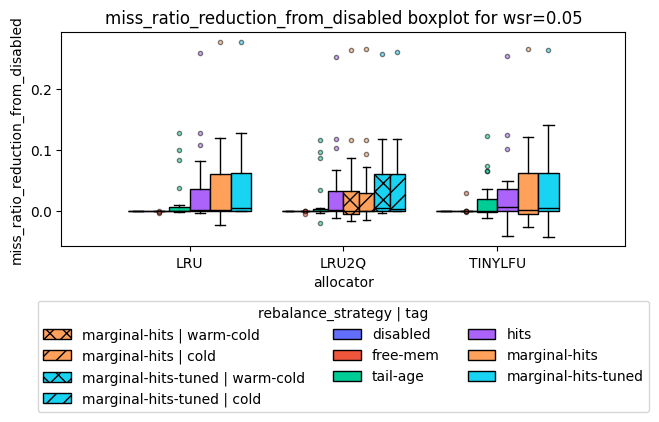

In [8]:
plot_box_modern_matplotlib(remapped_df, wsr=0.05, y="miss_ratio_reduction_from_disabled", x="allocator", color="rebalance_strategy", tag_col="tag")

In [130]:
remapped_df[remapped_df['miss_ratio_reduction_from_disabled'] < -0.001]

,trace_name,number_of_requests,wsr,slab_size,slab_cnt,rebalance_strategy,allocator,tag,miss_ratio,n_rebalanced_slabs,monitor_interval,n_alloc_failures,uuid,miss_ratio_reduction_from_disabled
250,meta_202210_kv,1482478166,0.05,4,1097,tail-age,TINYLFU,None,0.067171,12512,100000,0,meta_202210_kv-53e3c75b8d7baf119a82e420dc6b18ab,-0.004408
96,meta_202401_kv,1191241025,0.05,4,583,tail-age,LRU2Q,None,0.096949,219,100000,0,meta_202401_kv-ce9043d488b94ae6efa188fefcb9a7b5,-0.004626
233,meta_202401_kv,1191241025,0.05,4,583,tail-age,TINYLFU,None,0.100101,9326,100000,0,meta_202401_kv-5ce8c2457584eaf75122155dcd66079d,-0.003809
15,twitter_cluster20,3663259123,0.05,1,535,marginal-hits,LRU,None,0.055902,35228,100000,2,twitter_cluster20-95e517e3d49c5c3910c304a74d4e...,-0.002159
144,twitter_cluster20,3663259123,0.05,1,535,marginal-hits,LRU2Q,warm-cold,0.056239,34152,100000,4,twitter_cluster20-3a37c69db350f1237605af01cbb1...,-0.007180
282,twitter_cluster20,3663259123,0.05,1,535,marginal-hits,LRU2Q,cold,0.055830,35197,100000,2,twitter_cluster20-9a3ba0f02403c3ec9d6362feaac5...,-0.006771
141,twitter_cluster20,3663259123,0.05,1,535,marginal-hits,TINYLFU,None,0.055734,35226,100000,2,twitter_cluster20-075894d3ba1f683bedff40df5503...,-0.003288
207,twitter_cluster20,3663259123,0.05,1,535,tail-age,TINYLFU,None,0.053460,5638,100000,9,twitter_cluster20-08e9ec8693b6baa6bbf5af764318...,-0.001015
270,twitter_cluster22,2030691718,0.05,1,2077,marginal-hits,LRU,None,0.281170,12218,100000,0,twitter_cluster22-3f1cb3f560366bc2c3e953bebb32...,-0.002576
177,twitter_cluster22,2030691718,0.05,1,2077,marginal-hits,LRU2Q,cold,0.271674,12608,100000,0,twitter_cluster22-4c3afd71cac8ad8b7d9ac3339250...,-0.009204


In [ ]:
"""
write a function process this df
group by trace_name, wsr, and allocator
for each group use the rwo whose rebalance_strategy = 'disabled' as the baseline
then for each row's miss ratio minus the baseline's miss ratio
compute a new columns miss ratio reduction from disabled
"""

In [81]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

def plot_bar_modern_matplotlib(
    df, trace_name, wsr, y="miss_ratio", x="allocator", color="rebalance_strategy", tag_col="tag"
):
    # Filter
    plot_df = df[(df["trace_name"] == trace_name) & (df["wsr"] == wsr)].copy()
    if plot_df.empty:
        print("No data for this filter.")
        return

    # Consistent order
    rebalance_order = [
        "disabled", "free-mem", "tail-age", "hits", "marginal-hits", "marginal-hits-tuned"
    ]
    tag_order = ["warm-cold", "cold"]

    # Set categorical types for correct sorting
    plot_df[color] = pd.Categorical(plot_df[color], categories=rebalance_order, ordered=True)
    if tag_col in plot_df.columns:
        plot_df[tag_col] = plot_df[tag_col].astype("object").fillna("")
        plot_df[tag_col] = pd.Categorical(plot_df[tag_col], categories=[""] + tag_order, ordered=True)

    # Sort for consistent plotting
    plot_df = plot_df.sort_values([x, color, tag_col])

    # Prepare bar positions
    allocators = plot_df[x].unique()
    n_alloc = len(allocators)
    bar_data = []
    for alloc in allocators:
        group = plot_df[plot_df[x] == alloc]
        for _, row in group.iterrows():
            bar_data.append((alloc, row[color], row[tag_col], row[y]))

    # Use Plotly color palette
    plotly_palette = [
        "#636EFA", "#EF553B", "#00CC96", "#AB63FA", "#FFA15A", "#19D3F3",
        "#FF6692", "#B6E880", "#FF97FF", "#FECB52"
    ]
    color_map = {k: plotly_palette[i % len(plotly_palette)] for i, k in enumerate(rebalance_order)}
    hatch_map = {"warm-cold": "xx", "cold": "//", "": ""}

    # Calculate bar positions
    fig, ax = plt.subplots(figsize=(7, 3.5))
    width = 0.8
    for i, alloc in enumerate(allocators):
        group = [b for b in bar_data if b[0] == alloc]
        n = len(group)
        for j, (alloc, reb, tag, val) in enumerate(group):
            pos = i - width/2 + width*(j+0.5)/n if n > 1 else i
            ax.bar(
                pos, val, width=width/n if n > 1 else width*0.95,
                color=color_map.get(reb, "#cccccc"),
                label=None,
                hatch=hatch_map.get(tag, ""),
                edgecolor="black"
            )

    # Set x-ticks and labels
    ax.set_xticks(range(n_alloc))
    ax.set_xticklabels(allocators)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f"{y} for {trace_name} (wsr={wsr})")

    # Combined legend for color and pattern
    legend_items = []
    for reb in rebalance_order:
        for tag in tag_order:
            if ((plot_df[color] == reb) & (plot_df[tag_col] == tag)).any():
                legend_items.append(
                    Patch(
                        facecolor=color_map[reb],
                        edgecolor='black',
                        label=f"{reb} | {tag}",
                        hatch=hatch_map[tag]
                    )
                )
    # Add legend for bars without tag if present
    for reb in rebalance_order:
        if ((plot_df[color] == reb) & (plot_df[tag_col] == "")).any():
            legend_items.append(
                Patch(
                    facecolor=color_map[reb],
                    edgecolor='black',
                    label=f"{reb}",
                    hatch=""
                )
            )

    ax.legend(
        handles=legend_items,
        title=f"{color} | tag",
        loc='upper center',
        bbox_to_anchor=(0.5, -0.22),
        ncol=3,
        frameon=True
    )

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.28)
    plt.show()

In [83]:
remapped_df['trace_name'].unique()

array(['twitter_cluster19', 'twitter_cluster49', 'twitter_cluster22',
       'twitter_cluster3', 'meta_202401_kv', 'twitter_cluster21',
       'twitter_cluster53', 'twitter_cluster10', 'twitter_cluster26',
       'twitter_cluster20', 'twitter_cluster45', 'twitter_cluster48',
       'twitter_cluster8', 'twitter_cluster50', 'twitter_cluster30',
       'twitter_cluster7', 'twitter_cluster35', 'meta_202210_kv'],
      dtype=object)

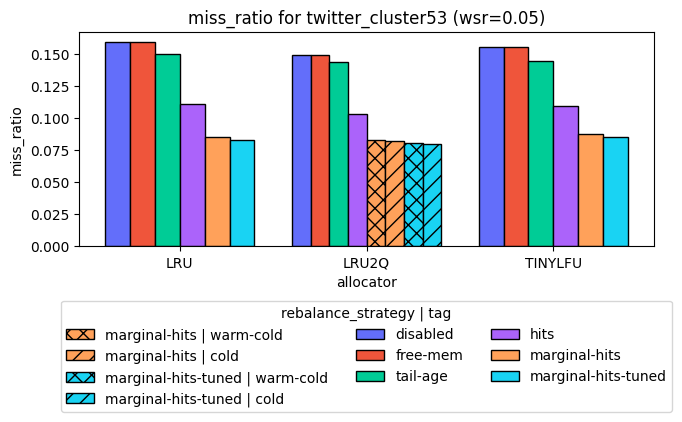

In [173]:
plot_bar_modern_matplotlib(remapped_df, "twitter_cluster53", 0.05)

In [ ]:
"""
process df for the rows whose rebalance_strategy is marginal-hits-tuned
use it's trace_name, wsr, allocator, tag to find the row with the same value and rebalance_strategy = marginal-hits

compute miss ratio of marginal-hits-tuned - the miss ratio of this found row, this diff will be added to a new column 
tuned_improvement
remember only rows whose rebalance_strategy is marginal-hits-tuned will have this new col
"""

In [ ]:
stats[(stats['trace_name'] == 'meta_202210_kv')].sort_values(by = "_missRatio")
"""
help me write a function, remap the df
rule:
1) rebalanceStrategy == marginal-hits-new -> rebalance_strategy = 'marginal-hits-tuned'
2) rebalanceStrategy == marginal-hits-old -> rebalance_strategy = 'marginal-hits'
other rebalanceStrategy values should be kept as is

allocator 
if TINYLFUTail -> allocator = 'TINYLFU'
if SIMPLE2Q -> allocator = LRU

tag:
if rebalanceStrategy == marginal-hits-new or rebalanceStrategy == marginal-hits-old and allocator = LRU2Q
if countColdTailHitsOnly == True -> tag = 'cold-tail' else tag 'warm-cold-tail'

_missRatio rename to miss_ratio
_rebalancerNumRebalancedSlabs rename to n_rebalanced_slabs
wakeUpRebalancerEveryXReqs rename to monitor_interval
_allocFailures rename to n_alloc_failures


other columns to keep trace_name, number_of_requests, wsr, slab_size, slab_cnt
"""

,trace_name,rebalanceStrategy,allocator,_missRatio,_rebalancerNumRebalancedSlabs,countColdTailHitsOnly,wakeUpRebalancerEveryXReqs
48,meta_202210_kv,marginal-hits-new,LRU2Q,0.034166,1626,True,100000
52,meta_202210_kv,marginal-hits-new,SIMPLE2Q,0.034222,1634,NaN,100000
10,meta_202210_kv,marginal-hits-new,TINYLFUTail,0.034270,1673,NaN,100000
32,meta_202210_kv,marginal-hits-new,LRU2Q,0.034311,2210,NaN,100000
54,meta_202210_kv,hits,LRU2Q,0.034472,2243,NaN,100000
14,meta_202210_kv,hits,SIMPLE2Q,0.034596,2257,NaN,100000
39,meta_202210_kv,hits,TINYLFU,0.034639,2234,NaN,100000
37,meta_202210_kv,marginal-hits-old,SIMPLE2Q,0.036264,14454,NaN,100000
12,meta_202210_kv,marginal-hits-old,TINYLFUTail,0.036340,14454,NaN,100000
6,meta_202210_kv,marginal-hits-old,LRU2Q,0.036966,14454,NaN,100000
